In [4]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path=kagglehub.dataset_download("colormap/spambase")
print(os.listdir(path))
file_path=os.path.join(path,"spambase.csv")
df=pd.read_csv(file_path)


['spambase.csv']


In [9]:
print(df.head)

<bound method NDFrame.head of       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0               0.00               0.64           0.64           0.0   
1               0.21               0.28           0.50           0.0   
2               0.06               0.00           0.71           0.0   
3               0.00               0.00           0.00           0.0   
4               0.00               0.00           0.00           0.0   
...              ...                ...            ...           ...   
4596            0.31               0.00           0.62           0.0   
4597            0.00               0.00           0.00           0.0   
4598            0.30               0.00           0.30           0.0   
4599            0.96               0.00           0.00           0.0   
4600            0.00               0.00           0.65           0.0   

      word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0              0.32         

In [13]:
print(df.info())
print(df.isna().sum())
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

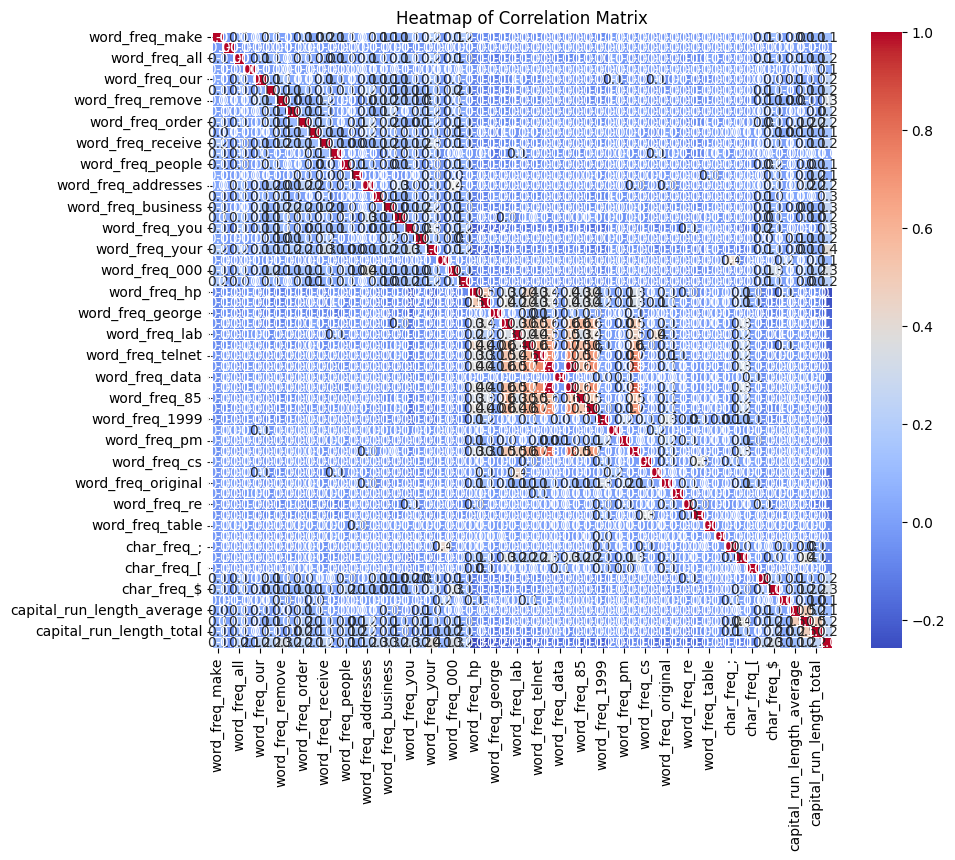

In [8]:
correlation=df.corr()
plt.figure(figsize=(10, 8))  # Điều chỉnh kích thước hình
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0.5)

# Hiển thị heatmap
plt.title("Heatmap of Correlation Matrix")
plt.show()

In [26]:
#preprocessing
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
model=GaussianNB()
y=df["spam"]
x=df.drop(columns=["spam"])
x_train,x_val,y_train,y_val=train_test_split(x,y,train_size=0.8)
scaler=StandardScaler()
temp=PCA(n_components=10)
column=x.columns
preprocessor=ColumnTransformer(
    transformers=[
        ("num",Pipeline(steps=[("scale",scaler),("PCA",temp)]),column)
    ]
)
my_pipeline=Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("model",model)
])


In [27]:
from sklearn.metrics import accuracy_score
my_pipeline.fit(x_train,y_train)
predict=my_pipeline.predict(x_val)
accuracy_score(y_val,predict)

0.8490770901194354